In [1]:
# tumor_identification_metrics.ipynb - plot metrics (F1 score etc) of tumor identification.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.patches import Patch

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/tumor_identification/vary_cna_profile'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/tumor_identification/vary_cna_profile/analysis/tumor_identification'

## Merge metrics from multiple experiments into one single file.

In [4]:
run_id_list = sorted([d for d in os.listdir(root_dir) if d.startswith('n')])
run_id_list

['n1', 'n2', 'n4']

In [5]:
dat = None
for run_id in run_id_list:
    print("processing '%s' ..." % run_id)
    run_dir = os.path.join(root_dir, run_id)
    metric_fn = os.path.join(run_dir, 'base/tumor_identification/2_metric/metrics.tsv')
    if not os.path.exists(metric_fn):
        print("[W] file '%s' does not exist!" % metric_fn)
        continue
    df = pd.read_csv(metric_fn, sep = '\t')
    df['run_id'] = run_id
    if dat is None:
        dat = df
    else:
        dat = pd.concat([dat, df], ignore_index = True)
    print("dat shape: %s" % str(dat.shape))
dat

processing 'n1' ...
dat shape: (20, 4)
processing 'n2' ...
dat shape: (45, 4)
processing 'n4' ...
dat shape: (70, 4)


,tool,metric,value,run_id
0,CopyKAT,accuracy,0.513514,n1
1,inferCNV,accuracy,0.877878,n1
2,Numbat,accuracy,0.991992,n1
3,XClone,accuracy,0.437437,n1
4,CopyKAT,precision,0.517157,n1
...,...,...,...,...
65,CalicoST,ARI,0.845803,n4
66,CopyKAT,ARI,0.995988,n4
67,inferCNV,ARI,1.000000,n4
68,Numbat,ARI,1.000000,n4


In [6]:
dat['tool'] = dat['tool'].replace({'CopyKat':'CopyKAT', 'inferCNV':'InferCNV'})
dat

,tool,metric,value,run_id
0,CopyKAT,accuracy,0.513514,n1
1,InferCNV,accuracy,0.877878,n1
2,Numbat,accuracy,0.991992,n1
3,XClone,accuracy,0.437437,n1
4,CopyKAT,precision,0.517157,n1
...,...,...,...,...
65,CalicoST,ARI,0.845803,n4
66,CopyKAT,ARI,0.995988,n4
67,InferCNV,ARI,1.000000,n4
68,Numbat,ARI,1.000000,n4


In [7]:
metric_fn = os.path.join(out_dir, 'tumor_identification.metrics.tsv')
dat.to_csv(
    metric_fn,
    sep = '\t',
    index = False
)

In [8]:
dat

,tool,metric,value,run_id
0,CopyKAT,accuracy,0.513514,n1
1,InferCNV,accuracy,0.877878,n1
2,Numbat,accuracy,0.991992,n1
3,XClone,accuracy,0.437437,n1
4,CopyKAT,precision,0.517157,n1
...,...,...,...,...
65,CalicoST,ARI,0.845803,n4
66,CopyKAT,ARI,0.995988,n4
67,InferCNV,ARI,1.000000,n4
68,Numbat,ARI,1.000000,n4


## Plot

In [9]:
dat = pd.read_csv(
    metric_fn,
    sep = '\t'
)
dat

,tool,metric,value,run_id
0,CopyKAT,accuracy,0.513514,n1
1,InferCNV,accuracy,0.877878,n1
2,Numbat,accuracy,0.991992,n1
3,XClone,accuracy,0.437437,n1
4,CopyKAT,precision,0.517157,n1
...,...,...,...,...
65,CalicoST,ARI,0.845803,n4
66,CopyKAT,ARI,0.995988,n4
67,InferCNV,ARI,1.000000,n4
68,Numbat,ARI,1.000000,n4


In [10]:
dat['run_id_raw'] = dat['run_id']
dat_raw = dat.copy()
dat['run_id'] = dat['run_id'].map({
    'n1':'1',
    'n2':'2',
    'n4':'4'
})
dat['run_id'] = pd.Categorical(
    dat['run_id'], 
    categories = [str(i) for i in (1, 2, 4)],
    ordered = True
)
dat

,tool,metric,value,run_id,run_id_raw
0,CopyKAT,accuracy,0.513514,1,n1
1,InferCNV,accuracy,0.877878,1,n1
2,Numbat,accuracy,0.991992,1,n1
3,XClone,accuracy,0.437437,1,n1
4,CopyKAT,precision,0.517157,1,n1
...,...,...,...,...,...
65,CalicoST,ARI,0.845803,4,n4
66,CopyKAT,ARI,0.995988,4,n4
67,InferCNV,ARI,1.000000,4,n4
68,Numbat,ARI,1.000000,4,n4


In [11]:
dat = dat[['tool', 'metric', 'run_id', 'value']].pivot(
    index = ['run_id', 'tool'],
    columns = 'metric',
    values = 'value'
).reset_index()
dat

metric,run_id,tool,ARI,F1,accuracy,precision,recall
0,1,CopyKAT,-0.000238,0.464758,0.513514,0.517157,0.422000
1,1,InferCNV,0.570738,0.881783,0.877878,0.855263,0.910000
2,1,Numbat,0.968193,0.992048,0.991992,0.986166,0.998000
3,1,XClone,0.014688,0.395699,0.437437,0.427907,0.368000
4,2,CalicoST,0.395813,0.832569,0.814956,0.715976,0.994521
5,2,CopyKAT,0.784595,0.937759,0.942966,0.946927,0.928767
6,2,InferCNV,0.974780,0.993141,0.993663,0.994505,0.991781
7,2,Numbat,1.000000,1.000000,1.000000,1.000000,1.000000
8,2,XClone,0.614917,0.872180,0.892269,0.966667,0.794521
9,4,CalicoST,0.845803,0.961315,0.959880,0.928972,0.995992


In [12]:
def plot_metrics(df, metric, metric_label, figsize = (9, 5), fontsize = 10, total_bar_width = 0.8, ymin = 0):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'F1', 'run_id'.
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric, 'run_id'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")
    
    # Ensure consistent ordering
    df = df.copy()
    df = df.sort_values(['run_id', 'tool']).reset_index(drop = True)

    # Pivot to get metric value per (run_id, tool, cna_type)
    pivot = df.pivot_table(
        index = 'run_id',
        columns = 'tool',
        values = metric,
        fill_value = -2
    )

    # Extract unique groups
    tool_order = ['InferCNV', 'CopyKAT', 'Numbat', 'XClone', 'CalicoST']
    run_ids = pivot.index.get_level_values('run_id').unique()
    tools = tool_order
    n_runs, n_tools = len(run_ids), len(tools)

    # Bar layout
    bar_width = total_bar_width / n_tools
    x_centers = np.arange(n_runs)

    # Colors
    tool_palette = [
        '#56B4E9',    # InferCNV
        '#E69F00',    # CopyKAT
        '#0072B2',    # Numbat
        '#F0E442',    # XClone
        '#D55E00'     # CalicoST
    ]
    tool_colors = [tool_palette[i % 100] for i in range(n_tools)]


    # Create plot
    fig, ax = plt.subplots(figsize = figsize)

    # Draw stacked bars
    y_star = 0.037
    for i, tool in enumerate(tools):
        for j, run in enumerate(run_ids):
            has_output = True
            if run in pivot.index:
                h = pivot.loc[run, tool]
                if h < -1:
                    has_output = False
            else:
                has_output = False
            x_pos = x_centers[j] + i * bar_width
            if has_output:
                ax.bar(
                    x_pos,
                    h,
                    bottom = 0,
                    width = bar_width,
                    color = tool_colors[i],
                    edgecolor = None,
                    linewidth = 0.5,
                    label = tool
                )
            else:
                ax.text(
                    x_pos, y_star,
                    '*', 
                    ha = 'center', va = 'top',
                    fontsize = fontsize - 2,
                    color = 'black',
                    weight = 'bold'
                )

    # Main axis styling
    ax.set_xticks(x_centers + bar_width * (n_tools - 1) / 2)
    ax.set_xticklabels(run_ids)
    ax.set_xlabel('Number of CNA events', size = fontsize + 1)
    ax.set_ylabel(metric_label, fontsize = fontsize + 1)
    ax.set_xlim(0 - bar_width, n_runs - 1 + bar_width * n_tools)
    ax.set_ylim(ymin, 1.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Title (lowered to avoid top panel)
    #fig.suptitle('AUROC by Run, Tool, and CNA Type', y=0.95)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #legend = fig.legend(
    #    [by_label[t] for t in tool_order], 
    #    tool_order, 
    #    title = None, 
    #    loc = 'upper center',
    #    frameon = False,
    #    ncol = 3,
    #    fontsize = fontsize,
    #    title_fontsize = fontsize,
    #    alignment = 'left',
    #    bbox_to_anchor = (0.53, 0.05)
    #)
    legend = fig.legend(
        [by_label[t] for t in tool_order], 
        tool_order, 
        title = 'Tool', 
        loc = 'upper left',
        frameon = False,
        fontsize = fontsize - 1,
        title_fontsize = fontsize - 1,
        alignment = 'left',
        bbox_to_anchor = (0.97, 0.84)
    )

    plt.tight_layout()
    return fig, ax

### Plot F1

In [13]:
metric = 'F1'
metric_label = 'F1 score'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,F1,run_id
0,CopyKAT,0.464758,1
1,InferCNV,0.881783,1
2,Numbat,0.992048,1
3,XClone,0.395699,1
4,CalicoST,0.832569,2


/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


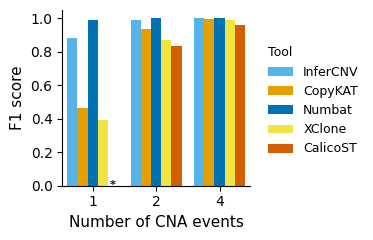

In [14]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.5), fontsize = 10)

In [15]:
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


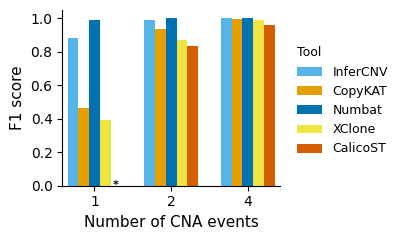

In [16]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (3, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.wide_version.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot accuracy

In [17]:
metric = 'accuracy'
metric_label = 'Accuracy'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,accuracy,run_id
0,CopyKAT,0.513514,1
1,InferCNV,0.877878,1
2,Numbat,0.991992,1
3,XClone,0.437437,1
4,CalicoST,0.814956,2


/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


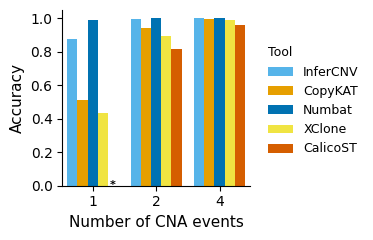

In [18]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.5), fontsize = 10)

In [19]:
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


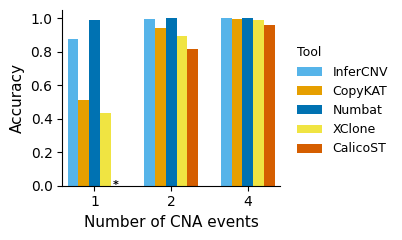

In [20]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (3, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.wide_version.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot precision

In [21]:
metric = 'precision'
metric_label = 'Precision'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,precision,run_id
0,CopyKAT,0.517157,1
1,InferCNV,0.855263,1
2,Numbat,0.986166,1
3,XClone,0.427907,1
4,CalicoST,0.715976,2


/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


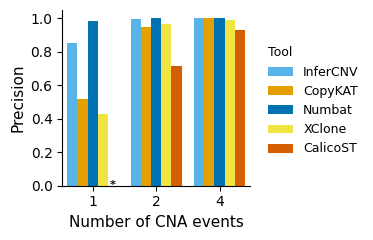

In [22]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


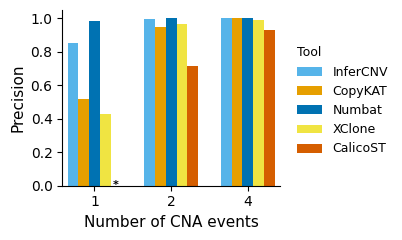

In [23]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (3, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.wide_version.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot recall

In [24]:
metric = 'recall'
metric_label = 'Recall'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,recall,run_id
0,CopyKAT,0.422000,1
1,InferCNV,0.910000,1
2,Numbat,0.998000,1
3,XClone,0.368000,1
4,CalicoST,0.994521,2


/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


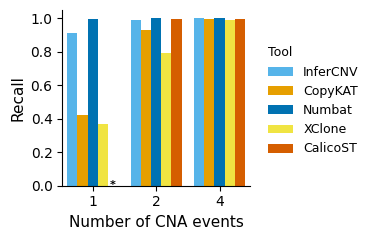

In [25]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


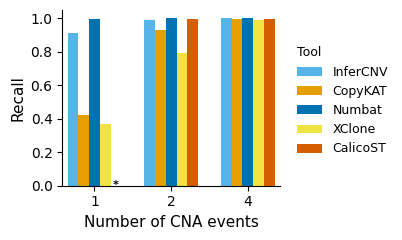

In [26]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (3, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.wide_version.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot ARI

In [27]:
metric = 'ARI'
metric_label = 'ARI'    # Adjusted Rand Index
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,ARI,run_id
0,CopyKAT,-0.000238,1
1,InferCNV,0.570738,1
2,Numbat,0.968193,1
3,XClone,0.014688,1
4,CalicoST,0.395813,2


/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


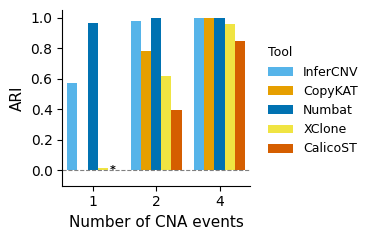

In [28]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.5), fontsize = 10, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_8675/3854182666.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


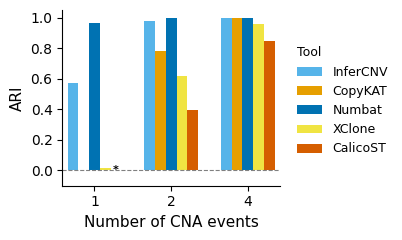

In [29]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (3, 2.5), fontsize = 10, total_bar_width = 0.7, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.wide_version.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')